# Практичне заняття №3
## Реалізація зворотного ланцюжка міркувань у Python

**Предметна область:** Помічник із вибору конфігурації ПК/Ноутбука

1. Програмна репрезентація бази знань.
2. Реалізація рекурсивного алгоритму зворотного виведення.
3. Реалізація інтерактивного запиту фактів.
4. Формування дерева доведення та модуля пояснення.
5. Тестування на сценаріях.
6. Візуалізація та аналіз.

## 1. Програмна репрезентація бази знань

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pprint import pprint

# Повна база правил
rules = [
    {"name": "R1",  "conditions": {"mobility": "yes"},                                                              "conclusion": ("form_factor", "laptop")},
    {"name": "R2",  "conditions": {"mobility": "no"},                                                               "conclusion": ("form_factor", "desktop")},
    {"name": "R3",  "conditions": {"mobility": "no", "priority": "portability"},                                    "conclusion": ("form_factor", "mini_pc")},
    {"name": "R4",  "conditions": {"primary_goal": "gaming", "form_factor": "desktop", "budget": "high"},            "conclusion": ("device_class", "premium_gaming_pc")},
    {"name": "R5",  "conditions": {"primary_goal": "gaming", "form_factor": "laptop",  "budget": "high"},            "conclusion": ("device_class", "gaming_laptop")},
    {"name": "R6",  "conditions": {"primary_goal": "gaming", "budget": "low"},                                      "conclusion": ("device_class", "budget_gaming_pc")},
    {"name": "R7",  "conditions": {"primary_goal": "office", "form_factor": "laptop",  "budget": "low"},             "conclusion": ("device_class", "budget_office_laptop")},
    {"name": "R8",  "conditions": {"primary_goal": "office", "priority": "portability", "form_factor": "laptop", "budget": "medium"}, "conclusion": ("device_class", "ultrabook")},
    {"name": "R9",  "conditions": {"primary_goal": "design_video", "os_preference": "macos", "form_factor": "laptop"}, "conclusion": ("device_class", "macbook_pro")},
    {"name": "R10", "conditions": {"primary_goal": "design_video", "form_factor": "desktop", "budget": "high"},      "conclusion": ("device_class", "professional_workstation")},
    {"name": "R11", "conditions": {"primary_goal": "basic_home", "form_factor": "laptop",  "priority": "battery_life"}, "conclusion": ("device_class", "chromebook_or_basic_laptop")},
    {"name": "R12", "conditions": {"primary_goal": "basic_home", "form_factor": "desktop", "budget": "low"},         "conclusion": ("device_class", "budget_home_desktop")},
    {"name": "R13", "conditions": {"device_class": "macbook_pro"},                                                  "conclusion": ("recommended_os", "macos")},
    {"name": "R14", "conditions": {"device_class": "premium_gaming_pc"},                                            "conclusion": ("recommended_os", "windows")},
    {"name": "R15", "conditions": {"device_class": "gaming_laptop"},                                               "conclusion": ("recommended_os", "windows")},
    {"name": "R16", "conditions": {"device_class": "professional_workstation"},                                     "conclusion": ("recommended_os", "windows_or_linux")},
    {"name": "R17", "conditions": {"device_class": "ultrabook"},                                                    "conclusion": ("recommended_os", "windows")},
]

# Приклад початкових фактів (Сценарій 1)
facts = {
    "primary_goal": "gaming",
    "budget": "high",
    "mobility": "no",
    "priority": "performance",
    "os_preference": "windows"
}

# Цільові гіпотези
goals = [
    ("recommended_os", "windows"),
    ("device_class",   "macbook_pro"),
    ("device_class",   "ultrabook"),
]

print(f"Завантажено {len(rules)} правил та {len(facts)} фактів.")

Завантажено 17 правил та 5 фактів.


## 2–4. Зворотний ланцюжок, інтерактивний запит та журнал доведення

In [2]:
def backward_chain(goal_attr, goal_value, working_memory, depth=0, visited=None, interactive=False):
    """
    Рекурсивний алгоритм зворотного виведення.
    Повертає (bool, log).
    """
    if visited is None:
        visited = set()
    indent = "  " * depth

    # Крок 1: факт вже відомий
    if working_memory.get(goal_attr) == goal_value:
        return True, [f"{indent}[Факт] {goal_attr} = {goal_value} підтверджено"]

    # Крок 2: шукаємо правила, що доводять ціль
    for rule in rules:
        res_attr, res_val = rule["conclusion"]
        if res_attr != goal_attr or res_val != goal_value:
            continue
        if rule["name"] in visited:
            continue

        log = [f"{indent}[Гіпотеза] Перевіряємо {rule['name']} для доведення {goal_attr}={goal_value}"]
        all_met = True
        sub_proofs = []

        for attr, val in rule["conditions"].items():
            visited.add(rule["name"])
            ok, sub_log = backward_chain(attr, val, working_memory, depth + 1, visited, interactive)
            sub_proofs.extend(sub_log)
            if not ok:
                all_met = False
                break

        if all_met:
            log.extend(sub_proofs)
            log.append(f"{indent}[Висновок] {rule['name']} спрацювало -> {goal_attr}={goal_value}")
            working_memory[goal_attr] = goal_value
            return True, log

    # Крок 3: інтерактивний запит — тільки для вхідних атрибутів
    is_input = not any(r["conclusion"][0] == goal_attr for r in rules)
    if interactive and is_input:
        print(f"\n--- СИСТЕМА ПИТАЄ: Чи правда, що '{goal_attr}' має значення '{goal_value}'? ---")
        answer = input("Введіть (y/n): ").strip().lower()
        if answer == "y":
            working_memory[goal_attr] = goal_value
            return True, [f"{indent}[Користувач] Підтверджено через запит: {goal_attr}={goal_value}"]

    return False, [f"{indent}[Помилка] Не вдалося довести {goal_attr}={goal_value}"]


def explain_result(goal, facts_db, is_interactive=False):
    g_attr, g_val = goal
    print(f"\n{'*' * 32}\nПЕРЕВІРКА ГІПОТЕЗИ: {g_attr} = {g_val}")
    success, journal = backward_chain(g_attr, g_val, facts_db, interactive=is_interactive)
    print("\nЖУРНАЛ ДОВЕДЕННЯ:")
    for entry in journal:
        print(entry)
    status = "ПІДТВЕРДЖЕНА" if success else "ВІДХИЛЕНА (недостатньо знань)"
    print(f"\nРЕЗУЛЬТАТ: Гіпотеза {status}")
    return success, journal

print("Функції backward_chain та explain_result визначено.")

Функції backward_chain та explain_result визначено.


## 5. Тестування на сценаріях

In [3]:
# Сценарій 1: Геймер — доведення recommended_os = windows (успішно)
print("=" * 50)
print("СЦЕНАРІЙ 1: Геймер (статично)")
facts_s1 = {"primary_goal": "gaming", "budget": "high", "mobility": "no", "priority": "performance"}
result_s1, log_s1 = explain_result(("recommended_os", "windows"), facts_s1)

СЦЕНАРІЙ 1: Геймер (статично)

********************************
ПЕРЕВІРКА ГІПОТЕЗИ: recommended_os = windows

ЖУРНАЛ ДОВЕДЕННЯ:
[Гіпотеза] Перевіряємо R14 для доведення recommended_os=windows
  [Гіпотеза] Перевіряємо R4 для доведення device_class=premium_gaming_pc
    [Факт] primary_goal = gaming підтверджено
    [Гіпотеза] Перевіряємо R2 для доведення form_factor=desktop
      [Факт] mobility = no підтверджено
    [Висновок] R2 спрацювало -> form_factor=desktop
    [Факт] budget = high підтверджено
  [Висновок] R4 спрацювало -> device_class=premium_gaming_pc
[Висновок] R14 спрацювало -> recommended_os=windows

РЕЗУЛЬТАТ: Гіпотеза ПІДТВЕРДЖЕНА


In [4]:
# Сценарій 2: Дизайнер Apple — доведення device_class = macbook_pro (успішно)
print("=" * 50)
print("СЦЕНАРІЙ 2: Дизайнер Apple (статично)")
facts_s2 = {"primary_goal": "design_video", "mobility": "yes", "os_preference": "macos", "budget": "high"}
result_s2, log_s2 = explain_result(("device_class", "macbook_pro"), facts_s2)

СЦЕНАРІЙ 2: Дизайнер Apple (статично)

********************************
ПЕРЕВІРКА ГІПОТЕЗИ: device_class = macbook_pro

ЖУРНАЛ ДОВЕДЕННЯ:
[Гіпотеза] Перевіряємо R9 для доведення device_class=macbook_pro
  [Факт] primary_goal = design_video підтверджено
  [Факт] os_preference = macos підтверджено
  [Гіпотеза] Перевіряємо R1 для доведення form_factor=laptop
    [Факт] mobility = yes підтверджено
  [Висновок] R1 спрацювало -> form_factor=laptop
[Висновок] R9 спрацювало -> device_class=macbook_pro

РЕЗУЛЬТАТ: Гіпотеза ПІДТВЕРДЖЕНА


In [5]:
# Сценарій 3: Відхилення — macbook_pro неможливий для геймера
print("=" * 50)
print("СЦЕНАРІЙ 3: Спроба довести macbook_pro для геймера (відхилення)")
facts_s3 = {"primary_goal": "gaming", "budget": "high", "mobility": "no"}
result_s3, log_s3 = explain_result(("device_class", "macbook_pro"), facts_s3)

СЦЕНАРІЙ 3: Спроба довести macbook_pro для геймера (відхилення)

********************************
ПЕРЕВІРКА ГІПОТЕЗИ: device_class = macbook_pro

ЖУРНАЛ ДОВЕДЕННЯ:
[Помилка] Не вдалося довести device_class=macbook_pro

РЕЗУЛЬТАТ: Гіпотеза ВІДХИЛЕНА (недостатньо знань)


In [6]:
# Сценарій 4: Інтерактивний — система сама запитує бракуючі факти
print("=" * 50)
print("СЦЕНАРІЙ 4: Офісний працівник (інтерактивно)")
facts_s4 = {"primary_goal": "office"}  # навмисно неповні факти
result_s4, log_s4 = explain_result(("device_class", "ultrabook"), facts_s4, is_interactive=True)

СЦЕНАРІЙ 4: Офісний працівник (інтерактивно)

********************************
ПЕРЕВІРКА ГІПОТЕЗИ: device_class = ultrabook

--- СИСТЕМА ПИТАЄ: Чи правда, що 'priority' має значення 'portability'? ---


Введіть (y/n):  y



--- СИСТЕМА ПИТАЄ: Чи правда, що 'mobility' має значення 'yes'? ---


Введіть (y/n):  y



--- СИСТЕМА ПИТАЄ: Чи правда, що 'budget' має значення 'medium'? ---


Введіть (y/n):  y



ЖУРНАЛ ДОВЕДЕННЯ:
[Гіпотеза] Перевіряємо R8 для доведення device_class=ultrabook
  [Факт] primary_goal = office підтверджено
  [Користувач] Підтверджено через запит: priority=portability
  [Гіпотеза] Перевіряємо R1 для доведення form_factor=laptop
    [Користувач] Підтверджено через запит: mobility=yes
  [Висновок] R1 спрацювало -> form_factor=laptop
  [Користувач] Підтверджено через запит: budget=medium
[Висновок] R8 спрацювало -> device_class=ultrabook

РЕЗУЛЬТАТ: Гіпотеза ПІДТВЕРДЖЕНА


## 6. Візуалізація дерева доведення

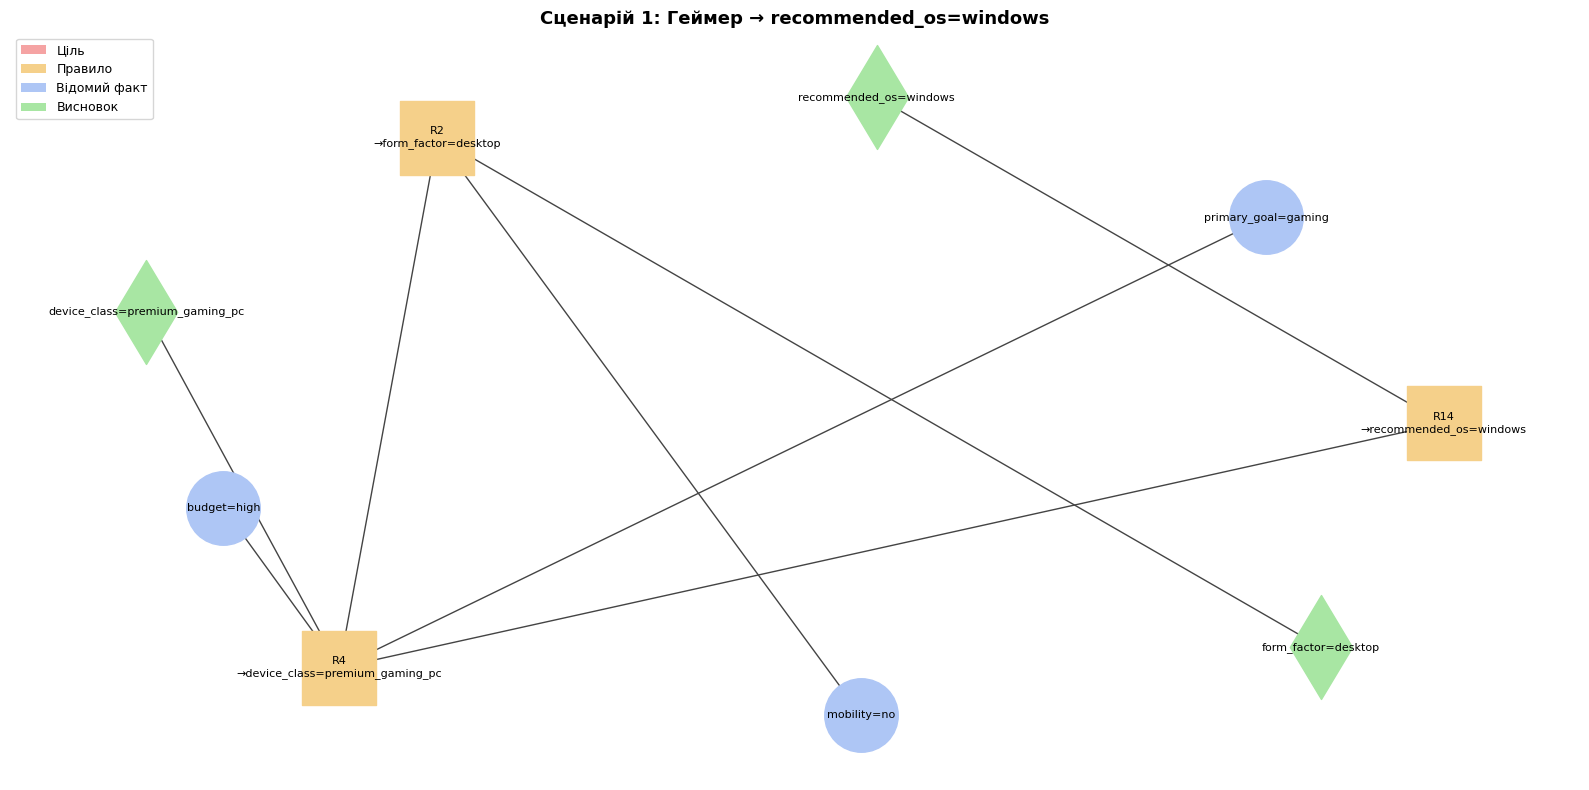

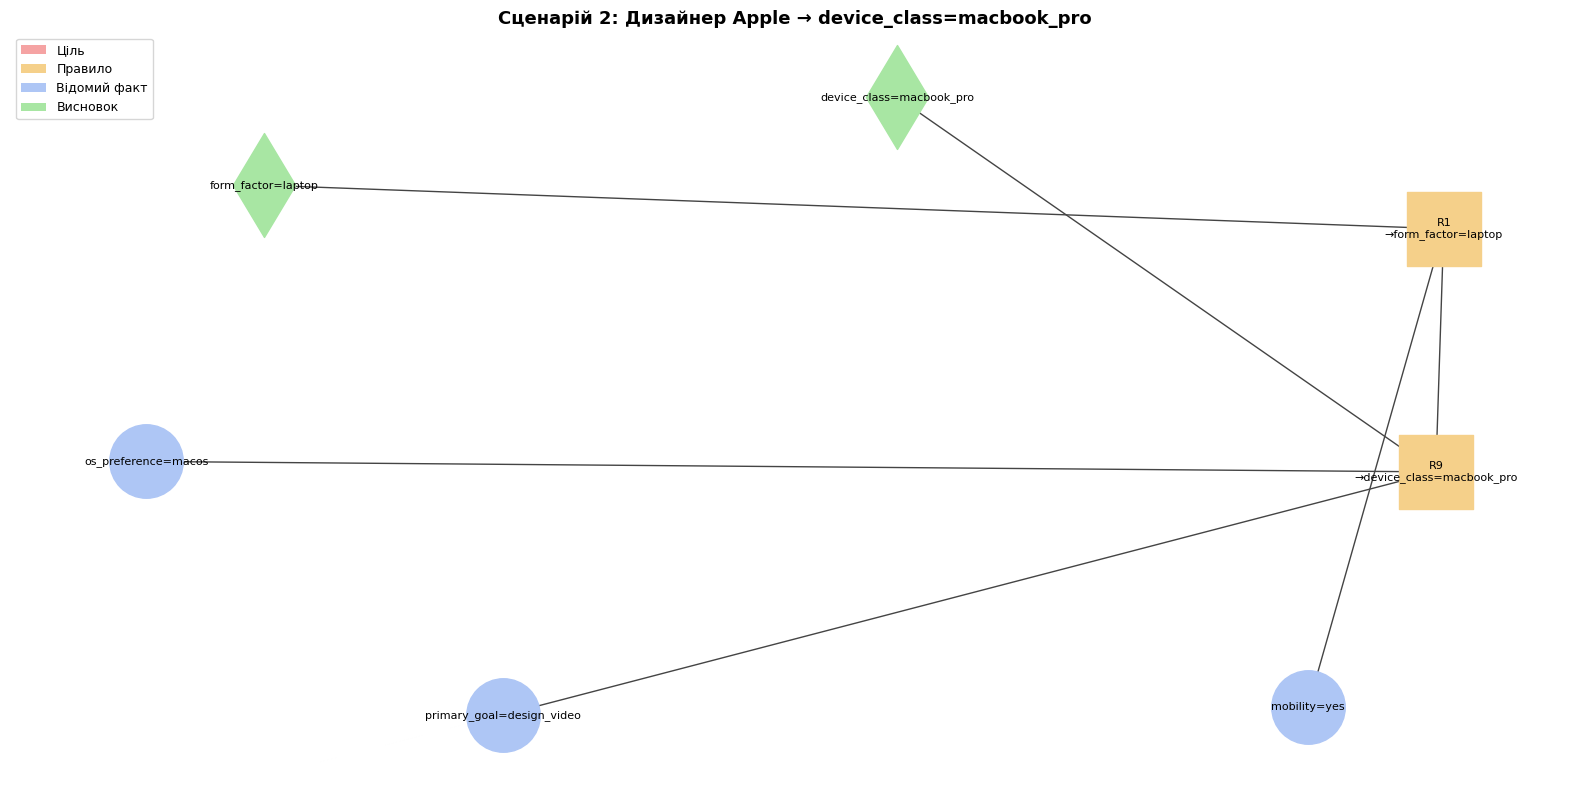

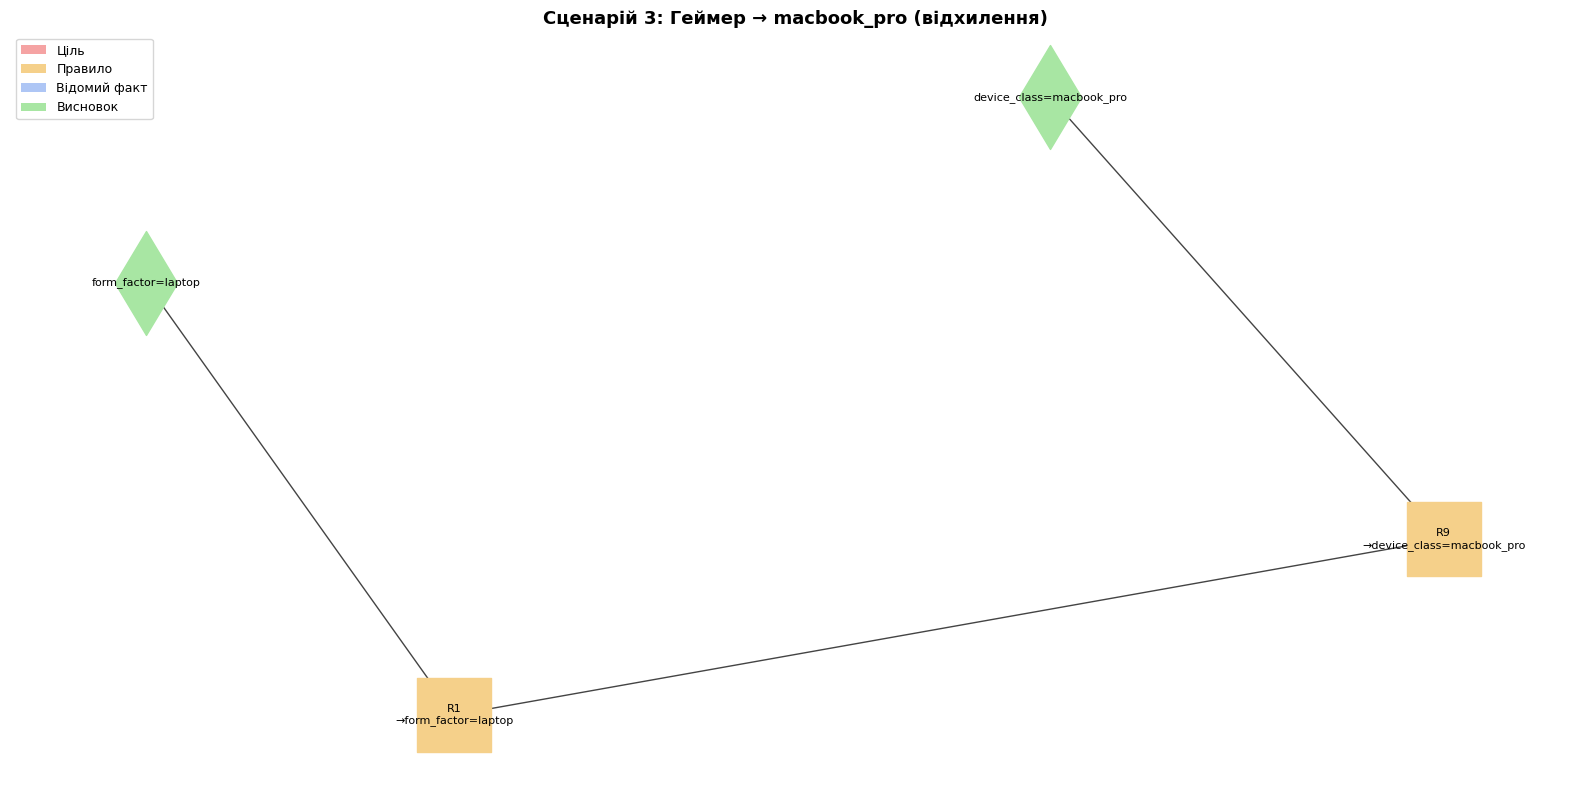

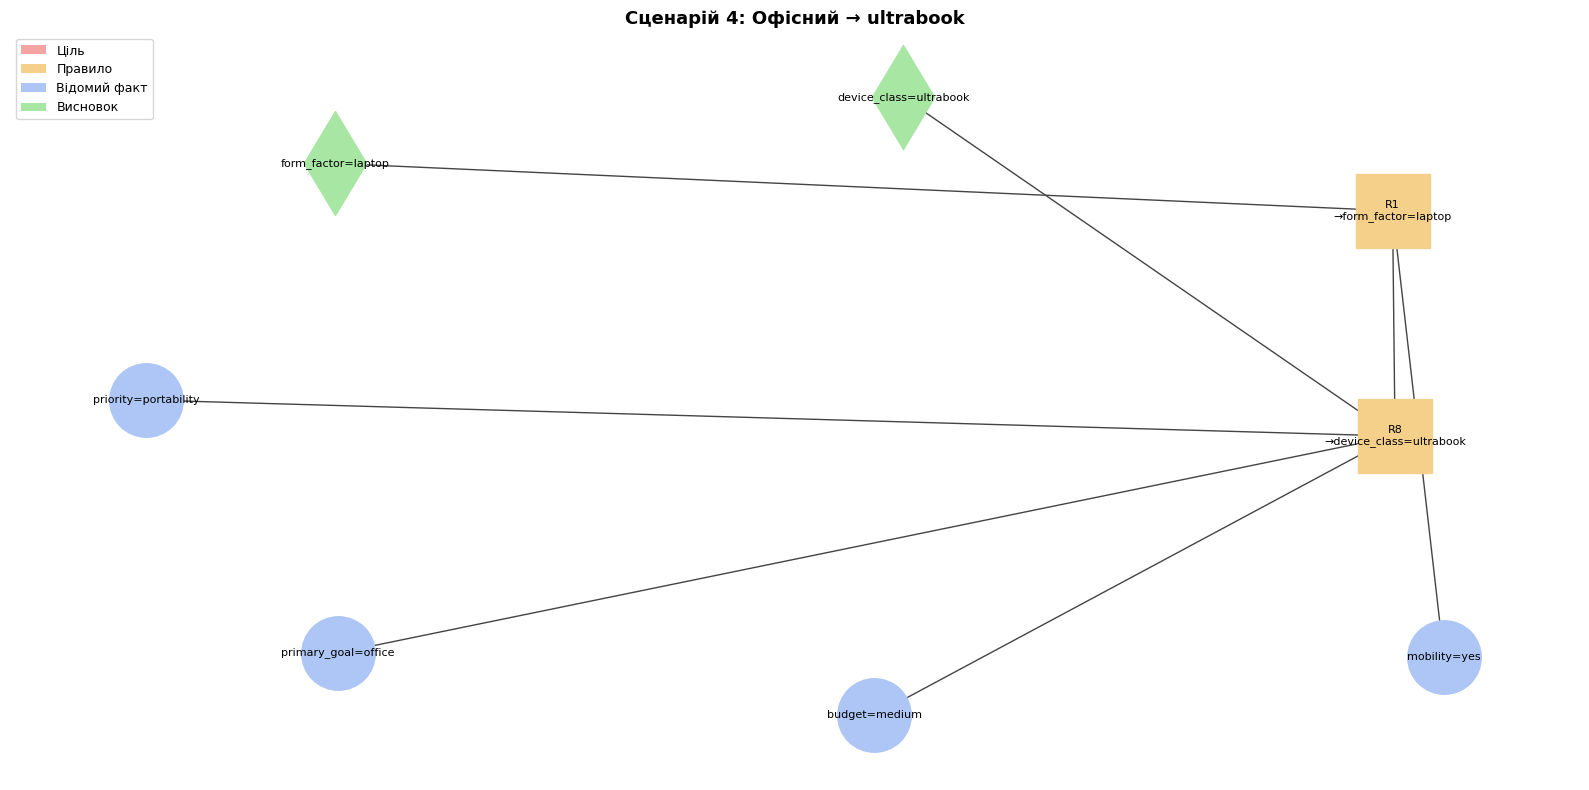

In [7]:
def build_proof_tree(goal_attr, goal_value, working_memory, visited=None):
    """Будує граф дерева доведення для візуалізації."""
    if visited is None:
        visited = set()
    G = nx.DiGraph()

    def recurse(attr, val, parent=None):
        node_id = f"{attr}={val}"

        if working_memory.get(attr) == val:
            G.add_node(node_id, node_type="fact")
            if parent:
                G.add_edge(parent, node_id)
            return

        for rule in rules:
            r_attr, r_val = rule["conclusion"]
            if r_attr == attr and r_val == val and rule["name"] not in visited:
                rule_node = f"{rule['name']}\n→{attr}={val}"
                visited.add(rule["name"])
                G.add_node(rule_node, node_type="rule")
                G.add_node(node_id, node_type="derived")
                if parent:
                    G.add_edge(parent, rule_node)
                G.add_edge(rule_node, node_id)
                for c_attr, c_val in rule["conditions"].items():
                    recurse(c_attr, c_val, rule_node)
                break

    root = f"{goal_attr}={goal_value}"
    G.add_node(root, node_type="goal")
    recurse(goal_attr, goal_value)
    return G


def draw_proof_tree(G, title):
    if len(G.nodes) == 0:
        print(f"[{title}] Граф порожній — немає що відображати.")
        return

    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=3.0)

    color_map = {"fact": "#aec6f5", "rule": "#f5d08a", "derived": "#a8e6a3", "goal": "#f5a3a3"}
    shape_map = {"fact": "o", "rule": "s", "derived": "d", "goal": "o"}

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_title(title, fontsize=13, fontweight="bold")

    for ntype in ["fact", "rule", "derived", "goal"]:
        nodes = [n for n, d in G.nodes(data=True) if d.get("node_type") == ntype]
        if nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes,
                                   node_shape=shape_map[ntype],
                                   node_size=2800, node_color=color_map[ntype], ax=ax)

    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=18,
                           edge_color="#444444", ax=ax)

    legend = [
        mpatches.Patch(facecolor="#f5a3a3", label="Ціль"),
        mpatches.Patch(facecolor="#f5d08a", label="Правило"),
        mpatches.Patch(facecolor="#aec6f5", label="Відомий факт"),
        mpatches.Patch(facecolor="#a8e6a3", label="Висновок"),
    ]
    ax.legend(handles=legend, loc="upper left", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Збираємо сценарії для візуалізації
viz_scenarios = [
    ("recommended_os", "windows",  {"primary_goal": "gaming",       "budget": "high", "mobility": "no"},              "Сценарій 1: Геймер → recommended_os=windows"),
    ("device_class",   "macbook_pro", {"primary_goal": "design_video", "mobility": "yes", "os_preference": "macos"},  "Сценарій 2: Дизайнер Apple → device_class=macbook_pro"),
    ("device_class",   "macbook_pro", {"primary_goal": "gaming",       "budget": "high", "mobility": "no"},            "Сценарій 3: Геймер → macbook_pro (відхилення)"),
    ("device_class",   "ultrabook",  {"primary_goal": "office", "mobility": "yes", "priority": "portability", "budget": "medium"}, "Сценарій 4: Офісний → ultrabook"),
]

for g_attr, g_val, wm, title in viz_scenarios:
    G = build_proof_tree(g_attr, g_val, dict(wm))
    draw_proof_tree(G, title)

## Аналіз результатів та висновки

1. **Сценарій 1 (Геймер):** Система успішно побудувала 3-рівневий ланцюжок: `mobility=no` → R2 → `form_factor=desktop` → R4 → `device_class=premium_gaming_pc` → R14 → `recommended_os=windows`. Алгоритм ретроспективно знайшов усі необхідні підцілі.

2. **Сценарій 2 (Дизайнер Apple):** Гіпотеза `device_class=macbook_pro` підтверджена через R9 (вимагає `os_preference=macos`, `form_factor=laptop`, `primary_goal=design_video`). Усі факти були у робочій пам'яті.

3. **Сценарій 3 (Відхилення):** Система коректно відхилила гіпотезу `macbook_pro` для геймера — R9 не виконується через `primary_goal=gaming`, і жодне інше правило не виводить `macbook_pro`.

4. **Сценарій 4 (Інтерактивний):** При неповних вхідних даних система самостійно запитала у користувача бракуючі атрибути (`mobility`, `priority`, `budget`), що дозволило довести гіпотезу `ultrabook`.

5. **Порівняння з прямим виведенням:** Зворотний ланцюжок є ефективнішим для перевірки конкретної гіпотези — він не розглядає всі правила, а цілеспрямовано йде від мети до фактів.

6. **Обмеження:** Якщо база правил не містить правила для певної комбінації (`basic_home + desktop + medium`), система не зможе ані підтвердити, ані спростувати гіпотезу — лише повідомить про відсутність знань.